WARNING *** file size (16747) not 512 + multiple of sector size (512)
WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero
Puntos cargados: 102
Rango I: [-5e-06,  5e-06]
Rango V: [-0.5106,  0.5011]
Columnas del archivo: ['Time', 'AI', 'AV', 'R']

──────────────────────────────────────
    #       Corriente         Voltaje
──────────────────────────────────────
    0    -5.00018e-06       -0.510562
    1    -4.80003e-06       -0.501598
    2     -4.6001e-06       -0.492117
    3    -4.40004e-06       -0.482473
    4    -4.20011e-06       -0.472336
  ...
   97    -4.20011e-06       -0.472181
   98    -4.40004e-06       -0.482235
   99     -4.6001e-06       -0.491842
  100    -4.80003e-06       -0.501301
  101    -5.00018e-06       -0.510472
──────────────────────────────────────

Puntos cargados: 102
Rango I: [-5e-06,  5e-06]
Rango V: [-0.5106,  0.5011]

Puntos en el rango ±3e-07: 6

── Resultado de la regresión lineal ──
  Pendiente  (dV/dI) = 232542  Ω
  Intercepto 

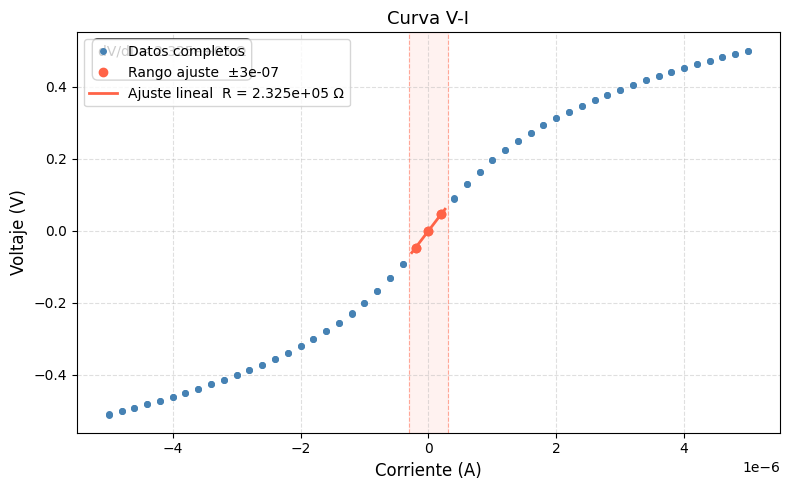


Gráfico guardado como  curva_vi.png


In [ ]:
"""
Análisis de curva V-I desde archivo Excel (.xls / .xlsx)
=========================================================
Columna A → Corriente (I)   [eje X]
Columna B → Voltaje   (V)   [eje Y]

Parámetros configurables al inicio del script.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os

# ──────────────────────────────────────────────
#  PARÁMETROS — modificá estos valores
# ──────────────────────────────────────────────

CARPETA        = r"./altest4"

# Etiquetas de los ejes (solo cosmético)
LABEL_X = "Corriente (A)"
LABEL_Y = "Voltaje (V)"
TITULO  = "Curva V-I"

# ──────────────────────────────────────────────
#  LECTURA DEL ARCHIVO
# ──────────────────────────────────────────────

engine = "xlrd" if ARCHIVO.lower().endswith(".xls") else "openpyxl"

df = pd.read_excel(
    os.path.join(CARPETA,ARCHIVO),
    engine=engine,
)

# Tomamos la 2da y 3era columna (índices 1 y 2)
corriente = df.iloc[:, 1].astype(float).values
voltaje   = df.iloc[:, 2].astype(float).values

print(f"Puntos cargados: {len(corriente)}")
print(f"Rango I: [{corriente.min():.4g},  {corriente.max():.4g}]")
print(f"Rango V: [{voltaje.min():.4g},  {voltaje.max():.4g}]")


# ──────────────────────────────────────────────
#  VERIFICACIÓN — primeros y últimos 5 puntos
# ──────────────────────────────────────────────
 
print(f"Columnas del archivo: {list(df.columns)}")
print(f"\n{'─'*38}")
print(f"{'#':>5}  {'Corriente':>14}  {'Voltaje':>14}")
print(f"{'─'*38}")
n = len(corriente)
indices = list(range(min(5, n)))
if n > 10:
    indices += [-1]  # separador
    indices += list(range(max(5, n - 5), n))
for i in indices:
    if i == -1:
        print(f"{'...':>5}")
    else:
        print(f"{i:>5}  {corriente[i]:>14.6g}  {voltaje[i]:>14.6g}")
print(f"{'─'*38}")
 
print(f"\nPuntos cargados: {len(corriente)}")
print(f"Rango I: [{corriente.min():.4g},  {corriente.max():.4g}]")
print(f"Rango V: [{voltaje.min():.4g},  {voltaje.max():.4g}]")

# ─────────────────────────────────────────────
#  SELECCIÓN DEL RANGO CENTRADO EN 0
# ──────────────────────────────────────────────

mitad = 3e-7
mascara = (corriente >= -mitad) & (corriente <= mitad)

I_fit = corriente[mascara]
V_fit = voltaje[mascara]

if len(I_fit) < 2:
    raise ValueError(
        f"Solo {len(I_fit)} punto(s) en el rango ±{mitad:.4g}. "
        "Ampliá RANGO_CORRIENTE."
    )

print(f"\nPuntos en el rango ±{mitad:.4g}: {len(I_fit)}")

# ──────────────────────────────────────────────
#  REGRESIÓN LINEAL → pendiente = dV/dI = R
# ──────────────────────────────────────────────

pendiente, intercepto, r_value, p_value, std_err = stats.linregress(I_fit, V_fit)

print(f"\n── Resultado de la regresión lineal ──")
print(f"  Pendiente  (dV/dI) = {pendiente:.6g}  Ω")
print(f"  Intercepto         = {intercepto:.6g}  V")
print(f"  Error estándar     = {std_err:.4g}")

# ──────────────────────────────────────────────
#  GRÁFICO
# ──────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 5))

# Todos los datos
ax.plot(corriente, voltaje, "o", markersize=4, color="steelblue",
        label="Datos completos", zorder=2)

# Puntos usados en el ajuste
ax.plot(I_fit, V_fit, "o", markersize=6, color="tomato",
        label=f"Rango ajuste  ±{mitad:.4g}", zorder=3)

# Línea de regresión extendida un poco más allá del rango
I_line = np.linspace(I_fit.min() * 1.3, I_fit.max() * 1.3, 200)
V_line = pendiente * I_line + intercepto
ax.plot(I_line, V_line, "-", color="tomato", linewidth=2,
        label=f"Ajuste lineal  R = {pendiente:.4g} Ω", zorder=4)

# Región del rango sombreada
ax.axvspan(-mitad, mitad, alpha=0.08, color="tomato", label="_nolegend_")
ax.axvline(-mitad, color="tomato", linewidth=0.8, linestyle="--", alpha=0.5)
ax.axvline( mitad, color="tomato", linewidth=0.8, linestyle="--", alpha=0.5)

ax.set_xlabel(LABEL_X, fontsize=12)
ax.set_ylabel(LABEL_Y, fontsize=12)
ax.set_title(TITULO, fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)

# Anotación con el resultado
textstr = (f"dV/dI = {pendiente:.4g} Ω\n")
ax.text(0.03, 0.97, textstr, transform=ax.transAxes,
        fontsize=10, verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig(f"curva_vi_{ARCHIVO}.png", dpi=150)
plt.show()
print("\nGráfico guardado como  curva_vi.png")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os
import glob

# ──────────────────────────────────────────────
#  CONFIGURACIÓN
# ──────────────────────────────────────────────
CARPETA = r"./altest4"
MITAD = 3e-7  # Rango para el ajuste lineal (I)
DELTA_SC = 0.2e-3  # Gap superconductor en eV (ajustar según tu material)

# Inicializar DesignHelper (asumiendo que ya está definido en tu entorno)
# dh = DesignHelper(light_speed="3e8 m/s") 

def procesar_archivos():
    resultados = []
    
    # Listar archivos .xls que NO contienen "(true_numbering)"
    archivos = [f for f in os.listdir(CARPETA) if f.endswith(".xls") and "(true_numbering)" not in f]
    
    print(f"Procesando {len(archivos)} archivos...")

    for archivo in archivos:
        path = os.path.join(CARPETA, archivo)
        try:
            df = pd.read_excel(path, engine="xlrd")
            corriente = df.iloc[:, 1].values
            voltaje = df.iloc[:, 2].values
            
            # Filtro para resistencia (región lineal cerca de 0)
            mascara = (corriente >= -MITAD) & (corriente <= MITAD)
            if len(corriente[mascara]) < 2: continue
            
            pendiente, _, _, _, _ = stats.linregress(corriente[mascara], voltaje[mascara])
            Rn = abs(pendiente) # Resistencia normal
            
            # Cálculo de Ic y Ej usando DesignHelper
            # Ic * Rn = PI * Delta / 2e
            Ic = (np.pi * DELTA_SC) / (2 * Rn) 
            Ej = (Ic * 2.0678e-15) / (2 * np.pi) # Ej = Ic * Phi0 / 2pi
            
            resultados.append({
                "Archivo": archivo,
                "Rn (Ohm)": Rn,
                "Ic (A)": Ic,
                "Ej (J)": Ej
            })
            
        except Exception as e:
            print(f"Error en {archivo}: {e}")

    return pd.DataFrame(resultados)

# Ejecutar y mostrar
df_resultados = procesar_archivos()
print("\nResumen de parámetros calculados:")
print(df_resultados)

# Guardar a CSV
df_resultados.to_csv("JJ_parameters_summary.csv", index=False)

In [ ]:
import sys
import os

# Option A: Use a relative path (e.g., up one level to a sibling folder)
sys.path.append(os.path.abspath("../../../design/parametric_coupling_test"))

In [9]:
from design_helper import DesignHelper
import pint
max_res = 5377 - 120
min_res = 290 - 120


helper = DesignHelper()
gap_energy = helper._energy_as_frequency(200 * helper.ureg.microeV)

min_ej = helper.Rn_to_EJ(max_res, gap_energy)
max_ej = helper.Rn_to_EJ(min_res, gap_energy)

In [12]:
min_ej

{'Ic': <Quantity(59.7601798, 'nanoampere')>,
 'EJ': <Quantity(29.6818959, 'gigahertz')>}

In [15]:
max_ej

{'Ic': <Quantity(1847.99568, 'nanoampere')>,
 'EJ': <Quantity(917.868982, 'gigahertz')>}

In [23]:
T = 75
Ec_max = max_ej["EJ"] / T
Ec_min = min_ej["EJ"] / T

In [24]:
max_C = helper.EC_to_C(Ec_min)
min_C = helper.EC_to_C(Ec_max)

print(f"min_C: {min_C}, max_C: {max_C} ")

min_C: 1.582760969778712 femtofarad, max_C: 48.94455540074523 femtofarad 
